Reading the Dataset
We will read the dataset and csv file using pandas also we will use some more libraries like numpy and matplotlib for data manipulation and visualization.

In [1]:
import pandas as pd  # For data manipulation
import numpy as np # For numerical operations
import time
import random  # For random number generation
from typing import List, Tuple # For type hinting
#import warnings
#warnings.filterwarnings("ignore")


In [2]:
# Loading the dataset
cities_df = pd.read_csv('../data/cities.csv')
cities_df.head()

,City,X,Y
0,City_1,37.454012,95.071431
1,City_2,73.199394,59.865848
2,City_3,15.601864,15.599452
3,City_4,5.808361,86.617615
4,City_5,60.111501,70.807258


# Here we will select 5 cities as a part of sampling

In [3]:
# Selecting the 5 samples from dataset
sample_cities = cities_df.head(5)
#sample_cities = cities_df
sample_cities

,City,X,Y
0,City_1,37.454012,95.071431
1,City_2,73.199394,59.865848
2,City_3,15.601864,15.599452
3,City_4,5.808361,86.617615
4,City_5,60.111501,70.807258


In [4]:
#Here I am extracting the coordinates
cities = sample_cities[['X', 'Y']].values.astype(float)
cities

array([[37.45401188, 95.07143064],
       [73.19939418, 59.86584842],
       [15.60186404, 15.59945203],
       [ 5.80836122, 86.61761458],
       [60.11150117, 70.80725778]])

# Measuring distance : Now we will follow euclidean distance to find the shortest distance between 2 points.

## Helper functions

In [5]:
#Function for calculating euclidean distance
def euclidean_distance(city1: Tuple[float, float], city2: Tuple[float, float]) -> float:
    return np.sqrt((city1[0] - city2[0])**2 + (city1[1] - city2[1])**2)

In [6]:
#Sample distance calculation between 2 cities
"""
This is a sample how the line of code is calculating distance . 
From the sample_cities variable we are taking the iloc and the X and Y coordinate values. After that passing this in the euclidean 
distance function which is calculating the distance between 2 points
"""
print(euclidean_distance((sample_cities.iloc[0]['X'], sample_cities.iloc[0]['Y']), (sample_cities.iloc[1]['X'], sample_cities.iloc[1]['Y'])))

50.17136010935256


Now we will create a function which will calculate total distance from a list

In [7]:
# Here this function does a total tour and calculates the net covered distance
# Each time the loop is running it is adding distance covered and upto returning
"""
This function is calculating total distance covered. Here we are passing a list of the available paths and then it is going in 
a loop which is adding distance between 2 cities and then doing a sum
"""
def calculate_total_distance(tour: List[int], cities: np.ndarray) -> float:
    total_dist = 0.0
    for i in range(len(tour)):
        city1 = cities[tour[i]]
        city2 = cities[tour[(i + 1) % len(tour)]]
        total_dist += euclidean_distance(city1, city2)
    return total_dist

In [8]:
def cities_based_on_numbers (number):
    return cities_df.head(number)[['X', 'Y']].values.astype(float)

## Setting Global Variable

In [9]:
# Here we will select 5 cities based on sample numbers
cities_coords = cities_based_on_numbers(20)
cities_coords

array([[37.45401188, 95.07143064],
       [73.19939418, 59.86584842],
       [15.60186404, 15.59945203],
       [ 5.80836122, 86.61761458],
       [60.11150117, 70.80725778],
       [ 2.05844943, 96.99098522],
       [83.24426408, 21.23391107],
       [18.18249672, 18.34045099],
       [30.4242243 , 52.47564316],
       [43.19450186, 29.12291402],
       [61.18528947, 13.94938607],
       [29.21446485, 36.63618433],
       [45.60699842, 78.51759614],
       [19.96737822, 51.42344384],
       [59.24145689,  4.64504127],
       [60.75448519, 17.05241237],
       [ 6.5051593 , 94.88855373],
       [96.56320331, 80.83973481],
       [30.46137692,  9.7672114 ],
       [68.42330265, 44.01524937]])

# Part 2 : Single Solution Algorithm Implementation

For better understanding and clean code we will apply the theory of object orientation. We will create a class for each individual type of algorithm.
Here we will use simulated annealing algorithmy.

## Simulated Annealing

In [33]:
class SimulatedAnnealing:
    """
    Simulated Annealing algorithm for solving TSP.

    This algorithm uses a probabilistic approach to escape local optima
    by accepting worse solutions with a probability that decreases over time.

    Time Complexity: O(iterations * n) where n is number of cities
    Space Complexity: O(n) for storing the tour
    """

    def __init__(self, cities: np.ndarray, initial_temp: float = 10000,
                 cooling_rate: float = 0.995, min_temp: float = 0.1):
        """
        Initialize Simulated Annealing algorithm.
        
        Args:
            cities: Array of city coordinates
            initial_temp: Starting temperature
            cooling_rate: Rate at which temperature decreases
            min_temp: Minimum temperature threshold
        """
        self.cities = cities
        self.n_cities = len(cities)
        self.initial_temp = initial_temp
        self.cooling_rate = cooling_rate
        self.min_temp = min_temp
        self.best_tour = None
        self.best_distance = float('inf')
        self.history = []

    def get_initial_solution(self):
        """
        Generate initial random solution.

        Time Complexity: O(n)
        Space Complexity: O(n)
        """
        tour = list(range(self.n_cities))
        random.shuffle(tour)
        return tour

    def get_neighbor(self, tour: List[int]):
        """
        Generating neighbor solution using 2-opt swap.

        Time Complexity: O(n)
        Space Complexity: O(n)
        """
        new_tour = tour.copy()
        i, j = sorted(random.sample(range(self.n_cities), 2))
        new_tour[i:j+1] = reversed(new_tour[i:j+1])
        return new_tour   

    def acceptance_probability(self, current_dist: float, new_dist: float,
                              temp: float):
        """
        Here we will calculate the probability of acccepting a worse solution 
        
        Time Complexity: O(1)
        Space Complexity: O(1)
        """
        if new_dist < current_dist:
            return 1.0
        return np.exp((current_dist - new_dist) / temp) 

    def solve(self, max_iterations: int = 10000):
        """
        here max_iterations is the Maximum number of iterations to run, we need a number of iterations for this algorithm
    
        This is how the function will work. 
        It will start with a random tour, then will try a small random change in the neighbor. If the tour is better it will 
        accept it else if it is worse then it will accept with a probability which depends on the temperature. 

        """
    
        # Generating initial random solution at first 
        current_tour = self.get_initial_solution()
    
        # After getting the current tour we will calculate the total distance which we declared earlier
        current_dist = calculate_total_distance(current_tour, self.cities)
    
        # Store the current best solution
        self.best_tour = current_tour.copy()
        self.best_distance = current_dist
    

        # Here we will initialize simulated annealing temperature and iteration counter
        temperature = self.initial_temp
        iteration = 0

        ## Adding a history collector for first iteration 
        self.history = [{
            'iteration': iteration,
            'temperature': temperature,
            'current_distance': current_dist,
            'best_distance': self.best_distance,
            'tour': current_tour.copy()
        }]
        
        # In this part we call a loop this loop is under while loop and it will run until the temperature is too low
        # Also after reaching maximum iterations
        while temperature > self.min_temp and iteration < max_iterations:
    
            # Here we are generating a neighbor of the current solution 
            new_tour = self.get_neighbor(current_tour)
    
            # Now calculating the total distance of the tour using previously declared function
            new_dist = calculate_total_distance(new_tour, self.cities)

            """Here now we will decide whether to accept the new tour or reject
            We compare new distance with current distance if the current distance is smaller than new distance then we 
            accept it other wise we will accept with probability 
            """

            if self.acceptance_probability(current_dist, new_dist, temperature) > random.random():
                # Accept move
                current_tour = new_tour
                current_dist = new_dist

                if current_dist < self.best_distance:
                    self.best_tour = current_tour.copy()
                    self.best_distance = current_dist
    
            # Here we will cool down the temperature by updating the old cooling temperature with cooling rate
            # This reduces the probability of accepting worse moves
            # as the algorithm progresses.
            temperature *= self.cooling_rate
    
            # Increasing iteration counter
            iteration += 1
    
            # Saving every 100 iterations
            if iteration % 100 == 0:
                self.history.append({
                    'iteration': iteration,
                    'temperature': temperature,
                    'current_distance': current_dist,
                    'best_distance': self.best_distance,
                    'tour': current_tour.copy()
                })
    
        return self.best_tour, self.best_distance


## Running the experiment on simulated annealing

In [24]:

print("Single  1: SIMULATED ANNEALING")

# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

# Initialize and run simulated annealing
sa = SimulatedAnnealing(
    cities=cities_coords,
    initial_temp=10000,
    cooling_rate=0.995,
    min_temp=0.1
)

start_time = time.time()
sa_best_tour, sa_best_distance = sa.solve(max_iterations=10000)
sa_time = time.time() - start_time

print(f"\nHyperparameters:")
print(f"Initial Temperature: {sa.initial_temp}")
print(f"Cooling Rate: {sa.cooling_rate}")
print(f"Minimum Temperature: {sa.min_temp}")
print(f"Max Iterations: 10000")

print(f"\nResults:")
print(f"Best Tour: {[f'City_{i+1}' for i in sa_best_tour]}")
print(f"Best Distance: {sa_best_distance:.4f}")
print(f"Execution Time: {sa_time:.4f} seconds")
print(f"Iterations Completed: {len(sa.history) * 100}")

# Saving simulated annealing results
sa_tour_sequence = [f"City_{i+1}" for i in sa_best_tour]
sa_results_df = pd.DataFrame({
    'Position': range(1, len(sa_tour_sequence) + 1),
    'City': sa_tour_sequence
})


Single  1: SIMULATED ANNEALING

Hyperparameters:
Initial Temperature: 10000
Cooling Rate: 0.995
Minimum Temperature: 0.1
Max Iterations: 10000

Results:
Best Tour: ['City_7', 'City_20', 'City_2', 'City_18', 'City_5', 'City_13', 'City_1', 'City_17', 'City_6', 'City_4', 'City_14', 'City_9', 'City_12', 'City_10', 'City_8', 'City_3', 'City_19', 'City_15', 'City_11', 'City_16']
Best Distance: 386.6267
Execution Time: 0.3117 seconds
Iterations Completed: 2300


## Tabu Search 

First we will create a class about tabu search to implement the tabu search feature. Using this we will find difference between the time and space complexity for 5 and 10 solution. Then according to that we will take decision which single solution algorithm we will chose to compare with genetic algorithm 

In [25]:
class TabuSearch:
    """
    Tabu Search algorithm for solving TSP.

    This algorithm explores the neighborhood aggressively but avoids cycling
    using a tabu list that forbids recently visited moves. An aspiration
    criterion allows tabu moves if they improve the global best solution.

    Time Complexity: O(iterations * n^2)
        - Each iteration evaluates a set of 2-opt neighbors O(n^2)
    Space Complexity: O(n + tabu_size)
        - Store one tour + tabu list
    """

    def __init__(self, cities, tabu_size=20, max_iterations=1000):
        """
        Initialize Tabu Search.

        Args:
            cities: Array of city coordinates
            tabu_size: Maximum length of tabu list
            max_iterations: Iteration budget
        """
        self.cities = cities
        self.n_cities = len(cities)
        self.tabu_size = tabu_size
        self.max_iterations = max_iterations
        self.best_tour = None
        self.best_distance = float('inf')
        self.history = []

        
    def get_initial_solution(self):
        """
        Generate initial random tour.

        Time Complexity: O(n)
        """
        tour = list(range(self.n_cities))
        random.shuffle(tour)
        return tour

    def get_neighbors(self, tour):
        """
        Generate neighbors using all possible 2-opt swaps.

        Time Complexity: O(n^2)
        Space Complexity: O(n^2) for storing neighbors
        """
        neighbors = []
        for i in range(self.n_cities-1):
            for j in range(i+1, self.n_cities):
                neighbor = tour.copy()
                neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
                neighbors.append((neighbor, (i,j)))
        return neighbors

    def solve(self):
        """
        Main Tabu Search loop.

        Steps:
        1. We will start with a random solution
        2. Evaluate all 2-opt neighbors
        3. Pick best non-tabu (or improving tabu) move
        4. Update tabu list
        5. Track global best
        """

        # Step 1: initial solution
        current_tour = self.get_initial_solution()
        current_distance = calculate_total_distance(current_tour, self.cities)
        self.best_tour = current_tour.copy()
        self.best_distance = current_distance

        tabu_list = []
        iteration = 0
        self.history = [{'iteration': 0, 'current_distance': current_distance, 'best_distance': current_distance}]

        while iteration < self.max_iterations:
            neighbors = [(t, move) for t, move in self.get_neighbors(current_tour) if move not in tabu_list]
            if not neighbors:
                # If locked out, allow all moves (reset)
                neighbors = self.get_neighbors(current_tour)
            neighbor_distances = [calculate_total_distance(t, self.cities) for t, _ in neighbors]
            best_neighbor_idx = np.argmin(neighbor_distances)
            best_neighbor, best_move = neighbors[best_neighbor_idx]
            best_neighbor_distance = neighbor_distances[best_neighbor_idx]

            current_tour = best_neighbor
            current_distance = best_neighbor_distance
            tabu_list.append(best_move)
            if len(tabu_list) > self.tabu_size:
                tabu_list.pop(0)

            if current_distance < self.best_distance:
                self.best_tour = current_tour.copy()
                self.best_distance = current_distance

            iteration += 1
            if iteration % 5 == 0:
                self.history.append({
                    'iteration': iteration,
                    'current_distance': current_distance,
                    'best_distance': self.best_distance
                })
        return self.best_tour, self.best_distance

## Running the experiment on Tabu Search

In [26]:
print("Single  2: TABU SEARCH")

# Set seed for reproducibility
random.seed(42)
ts = TabuSearch(cities=cities_coords, tabu_size=10, max_iterations=500)
start = time.time()
ts_best_tour, ts_best_distance = ts.solve()
ts_time = time.time() - start

print(f'Best Tabu tour (5 cities): {[f"City_{i+1}" for i in ts_best_tour]}')
print(f'Best Tabu distance: {ts_best_distance:.3f}, Execution time: {ts_time:.4f}s')

Single  2: TABU SEARCH
Best Tabu tour (5 cities): ['City_4', 'City_6', 'City_17', 'City_1', 'City_13', 'City_5', 'City_18', 'City_2', 'City_20', 'City_7', 'City_15', 'City_11', 'City_16', 'City_10', 'City_19', 'City_3', 'City_8', 'City_12', 'City_9', 'City_14']
Best Tabu distance: 386.430, Execution time: 6.4522s


The time complexity we saw in here it shows that the execution time difference is so low. In this context we will try with larger set of datas and find the best one. 

In [27]:
print ('Simulated Annealing')
# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

# Initialize and run simulated annealing
sa = SimulatedAnnealing(
    cities=cities_coords,
    initial_temp=10000,
    cooling_rate=0.995,
    min_temp=0.1
)

start_time = time.time()
sa_best_tour, sa_best_distance = sa.solve(max_iterations=10000)
sa_time = time.time() - start_time

print(f"\nResults:")
print(f"Best Tour: {[f'City_{i+1}' for i in sa_best_tour]}")
print(f"Best Distance: {sa_best_distance:.4f}")
print(f"Execution Time: {sa_time:.4f} seconds")
print(f"Iterations Completed: {len(sa.history) * 100}")

# Saving simulated annealing results
sa_tour_sequence = [f"City_{i+1}" for i in sa_best_tour]
sa_results_df = pd.DataFrame({
    'Position': range(1, len(sa_tour_sequence) + 1),
    'City': sa_tour_sequence
})

##
print("TABU SEARCH")

# Set seed for reproducibility
random.seed(42)
ts = TabuSearch(cities=cities_coords, tabu_size=10, max_iterations=500)
start = time.time()
ts_best_tour, ts_best_distance = ts.solve()
ts_time = time.time() - start

print(f'Best Tabu tour : {[f"City_{i+1}" for i in ts_best_tour]}')
print(f'Best Tabu distance: {ts_best_distance:.3f}, Execution time: {ts_time:.4f}s')

Simulated Annealing

Results:
Best Tour: ['City_7', 'City_20', 'City_2', 'City_18', 'City_5', 'City_13', 'City_1', 'City_17', 'City_6', 'City_4', 'City_14', 'City_9', 'City_12', 'City_10', 'City_8', 'City_3', 'City_19', 'City_15', 'City_11', 'City_16']
Best Distance: 386.6267
Execution Time: 0.2986 seconds
Iterations Completed: 2300
TABU SEARCH
Best Tabu tour : ['City_4', 'City_6', 'City_17', 'City_1', 'City_13', 'City_5', 'City_18', 'City_2', 'City_20', 'City_7', 'City_15', 'City_11', 'City_16', 'City_10', 'City_19', 'City_3', 'City_8', 'City_12', 'City_9', 'City_14']
Best Tabu distance: 386.430, Execution time: 6.1173s


As we can see comparing the results the execution time is more for tabu search and for simulated annealing it is very less time just for 20 cities. Even though shortest distance is same but comparing time and space complexity between tabu and simulated annealing we will choose simulated annealing for single search algorithm. 

## Simulated Annealing plot

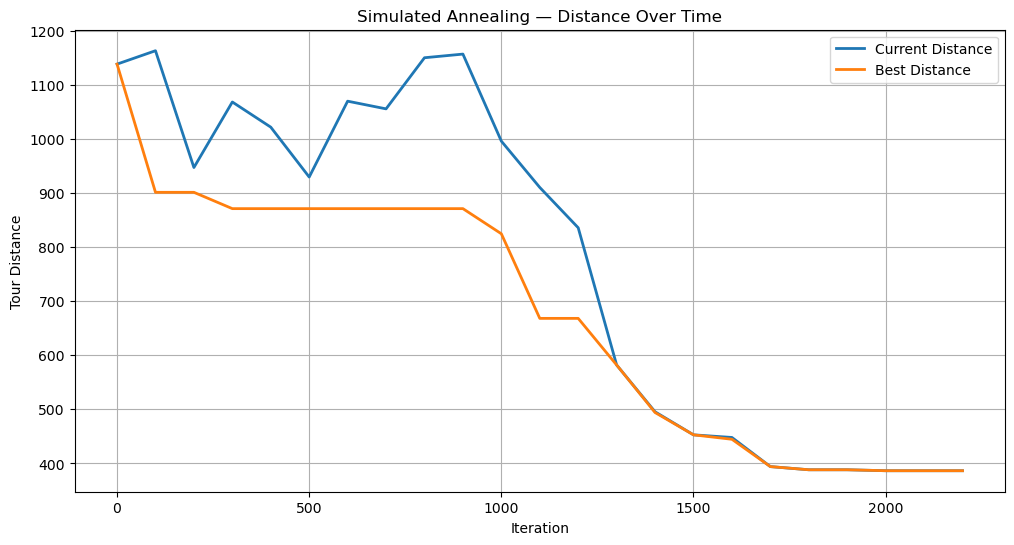

In [28]:
# Generative ai help was taken for plotting the graph
import matplotlib.pyplot as plt

def plot_sa_history(sa_history):
    """
    Plot of Simulated Annealing performance over iterations.
    Here sa_history is the list of dictionaries which contains iteration , temperature , current_distance and best_distance
    We have appended inside sa history in the solve function 
    """
    iterations = [h['iteration'] for h in sa_history]
    current_distances = [h['current_distance'] for h in sa_history]
    best_distances = [h['best_distance'] for h in sa_history]

    plt.figure(figsize=(12, 6))
    plt.plot(iterations, current_distances, label="Current Distance", linewidth=2)
    plt.plot(iterations, best_distances, label="Best Distance", linewidth=2)

    plt.xlabel("Iteration")
    plt.ylabel("Tour Distance")
    plt.title("Simulated Annealing — Distance Over Time")
    plt.grid(True)
    plt.legend()
    plt.show()

# Calling the function using sa
plot_sa_history(sa.history)


This graph shows how the tour distance changes over Simulated Annealing iterations for the 20‑city instance drawn cities.csv coordinates.

The blue line is the distance of the tour that the algorithm is currently exploring at the moments logged to sa.history, it moves up and down because simulated annealing sometimes accepts worse tour based on probability to escape local optima.

The orange line is the best (shortest) tour distance found so far, which quickly drops to a low value near the start and then stays flat because no better tour is discovered later in the run.

The fact that the blue line keeps oscillating while the orange line is flat means the algorithm is still exploring different tours, but all of them are worse than the best one it has already found, so the global best solution does not improve after that early point.

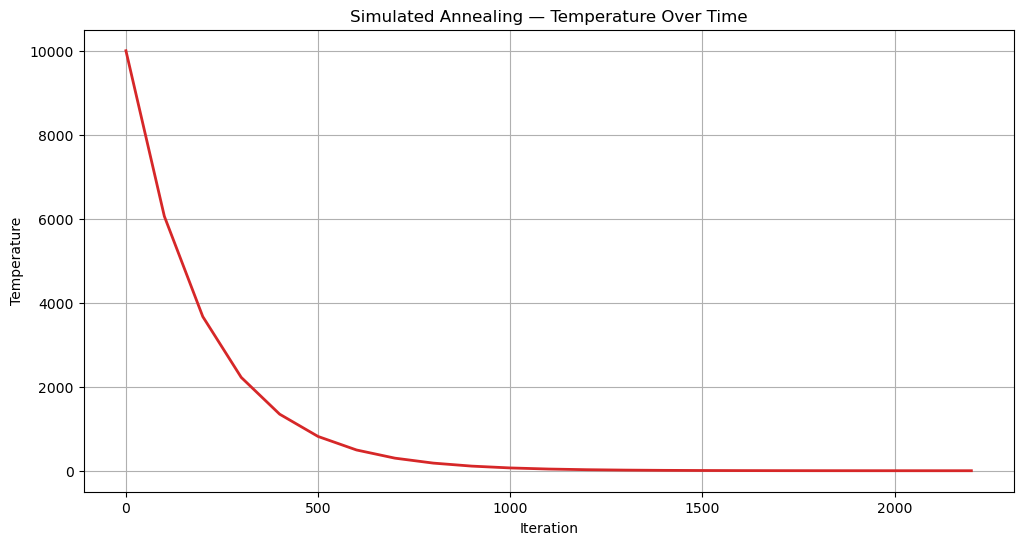

In [29]:
def plot_sa_temperature(sa_history):
    """
    Plot of Simulated Annealing temperature over iterations.
    Uses the 'iteration' and 'temperature' values stored in sa_history.
    """
    iterations = [h['iteration'] for h in sa_history]
    temperatures = [h['temperature'] for h in sa_history]

    plt.figure(figsize=(12, 6))
    plt.plot(iterations, temperatures, color="tab:red", linewidth=2)

    plt.xlabel("Iteration")
    plt.ylabel("Temperature")
    plt.title("Simulated Annealing — Temperature Over Time")
    plt.grid(True)
    plt.show()

# Call after running SA
plot_sa_temperature(sa.history)


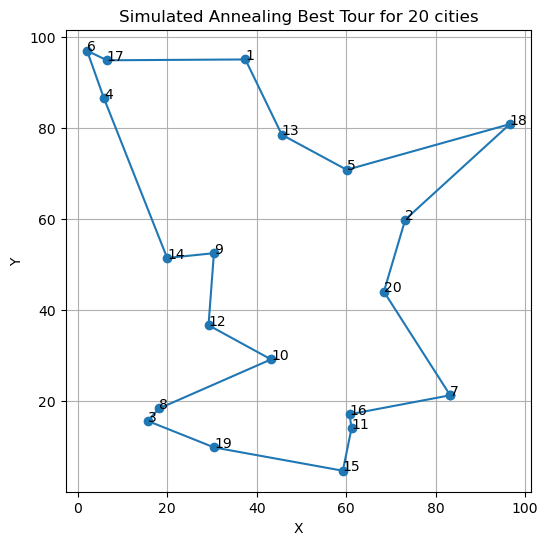

In [30]:
# Plot best tour found
def plot_tour(coords, tour, title="TSP Tour"):
    tour_c = tour + [tour[0]]  # close the loop
    xs = coords[tour_c, 0]
    ys = coords[tour_c, 1]

    plt.figure(figsize=(6, 6))
    plt.plot(xs, ys, marker='o')
    for i, txt in enumerate(tour):
        plt.annotate(f"{txt+1}", (coords[tour[i]][0], coords[tour[i]][1]))
    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True)
    plt.show()
plot_tour(cities_coords, sa_best_tour, title="Simulated Annealing Best Tour for 20 cities")

## Scalibility Testing

For the simulated annealing we have created the algorithm to measure the optimum path. Now we will do scalibility testing and put them in a csv file for further analysis

In [65]:
# This function will run simulated annealing based on the number of cities. We will change the number of cities 10,20,30,40,50
# After that we will keep the results in a csv file for future analysis 
# From the csv we will get the view how it is improving distance slowly
def run_sa_with_brief_log (num_cities,
                initial_temp=10000,
                cooling_rate=0.995,
                min_temp=0.1,
                max_iterations=10000):
    """
    Running Simulated Annealing once for a given problem size.
    Also saving per-iteration tour and distance in a CSV file.
    """
    cities = cities_based_on_numbers(num_cities)

    # reproducibility
    random.seed(42)
    np.random.seed(42)

    sa = SimulatedAnnealing(
        cities=cities,
        initial_temp=initial_temp,
        cooling_rate=cooling_rate,
        min_temp=min_temp
    )

    start_time = time.time()
    best_tour, best_distance = sa.solve(max_iterations=max_iterations)
    elapsed = time.time() - start_time

    # Each row: iteration, current_distance, best_distance, route as string
    hist_rows = []
    for h in sa.history:
        tour = h['tour']
        tour_cities = " -> ".join([f"City_{i+1}" for i in tour])
        hist_rows.append({
            "iteration": h["iteration"],
            "temperature": h["temperature"],
            "current_distance": h["current_distance"],
            "best_distance": h["best_distance"],
            "route": tour_cities
        })

    hist_df = pd.DataFrame(hist_rows)

    # Save to CSV, e.g. sa_history_20cities.csv
    hist_filename = f"../results/sa_history_{num_cities}cities.csv"
    hist_df.to_csv(hist_filename, index=False)
    print(f"Per-iteration SA history saved to {hist_filename}")

    # brief result for scalability summary 
    result = {
        "n_cities": num_cities,
        "best_distance": best_distance,
        "time_sec": elapsed,
        "iterations_logged": len(sa.history) * 5  # since you log every 5 iters
    }
    return result



In [66]:
# For each run this function will let us find the time and space complexity
def run_sa_once(num_cities,
                initial_temp=10000,
                cooling_rate=0.995,
                min_temp=0.1,
                max_iterations=10000):
    """
    Run Simulated Annealing once for a given problem size.
    Returns brief metrics for scalability analysis.
    """
    cities = cities_based_on_numbers(num_cities)

    # reproducibility
    random.seed(42)
    np.random.seed(42)

    sa = SimulatedAnnealing(
        cities=cities,
        initial_temp=initial_temp,
        cooling_rate=cooling_rate,
        min_temp=min_temp
    )

    start_time = time.time()
    best_tour, best_distance = sa.solve(max_iterations=max_iterations)
    elapsed = time.time() - start_time

    # brief result: only what we need
    return {
        "n_cities": num_cities,
        "best_distance": best_distance,
        "time_sec": elapsed,
        # if you log every 100 iterations, each history row = 100 iters
        "iterations_effective": len(sa.history) * 100
    }


In [67]:
# In here we will measure with different city size and collect the time complexity
city_sizes = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
sa_results = []

print("Simulated Annealing – scalability test")

for n in city_sizes:
    # run_sa_once now also saves sa_history_{n}cities.csv internally
    res = run_sa_once(num_cities=n)
    sa_results.append(res)
    print(f"{n:2d} cities -> "
          f"best_distance={res['best_distance']:.3f}, "
          f"time={res['time_sec']:.4f}s, "
          f"iters≈{res['iterations_effective']}")

# Build DataFrame with brief metrics
sa_scal_df = pd.DataFrame(sa_results)

print("\nSA scalability summary")
print(sa_scal_df[["n_cities", "best_distance", "time_sec",
                  "iterations_effective"]].to_string(index=False))

# Save overall scalability table for plots / report
sa_scal_df.to_csv("../results/sa_history_10-50_cities.csv", index=False)
print("\nSaved overall scalability results to sa_scalability_10_50.csv")


Simulated Annealing – scalability test
 5 cities -> best_distance=227.346, time=0.0778s, iters≈2300
10 cities -> best_distance=290.307, time=0.0734s, iters≈2300
15 cities -> best_distance=320.526, time=0.1085s, iters≈2300
20 cities -> best_distance=386.627, time=0.1468s, iters≈2300
25 cities -> best_distance=463.845, time=0.1674s, iters≈2300
30 cities -> best_distance=523.782, time=0.1604s, iters≈2300
35 cities -> best_distance=558.850, time=0.2060s, iters≈2300
40 cities -> best_distance=582.591, time=0.2671s, iters≈2300
45 cities -> best_distance=687.274, time=0.2697s, iters≈2300
50 cities -> best_distance=755.074, time=0.2998s, iters≈2300

SA scalability summary
 n_cities  best_distance  time_sec  iterations_effective
        5     227.345519  0.077764                  2300
       10     290.306774  0.073357                  2300
       15     320.525666  0.108515                  2300
       20     386.626677  0.146817                  2300
       25     463.844632  0.167430        

In [68]:
city_sizes = [10, 20, 30, 40, 50]
all_results = []

for n in city_sizes:
    res = run_sa_with_brief_log(n)   # Finding history of path finding
    all_results.append(res)


Per-iteration SA history saved to ../results/sa_history_10cities.csv
Per-iteration SA history saved to ../results/sa_history_20cities.csv
Per-iteration SA history saved to ../results/sa_history_30cities.csv
Per-iteration SA history saved to ../results/sa_history_40cities.csv
Per-iteration SA history saved to ../results/sa_history_50cities.csv


In [57]:
# We may not need this later remove this
"""
city_sizes = [10, 20, 30, 40, 50]
sa_results = []

print("Simulated Annealing – scalability test")

for n in city_sizes:
    res = run_sa_once(num_cities=n)
    sa_results.append(res)
    print(f"{n:2d} cities -> "
          f"best_distance={res['best_distance']:.3f}, "
          f"time={res['time_sec']:.4f}s, "
          f"iters≈{res['iterations_logged']}")

sa_scal_df = pd.DataFrame(sa_results)
print("\nSA scalability summary")
print(sa_scal_df[["n_cities", "best_distance", "time_sec",
                  "iterations_logged"]].to_string(index=False))

# optional: save for plots
sa_scal_df.to_csv("../results/sa_scalability_10_50.csv", index=False)
"""

'\ncity_sizes = [10, 20, 30, 40, 50]\nsa_results = []\n\nprint("Simulated Annealing – scalability test")\n\nfor n in city_sizes:\n    res = run_sa_once(num_cities=n)\n    sa_results.append(res)\n    print(f"{n:2d} cities -> "\n          f"best_distance={res[\'best_distance\']:.3f}, "\n          f"time={res[\'time_sec\']:.4f}s, "\n          f"iters≈{res[\'iterations_logged\']}")\n\nsa_scal_df = pd.DataFrame(sa_results)\nprint("\nSA scalability summary")\nprint(sa_scal_df[["n_cities", "best_distance", "time_sec",\n                  "iterations_logged"]].to_string(index=False))\n\n# optional: save for plots\nsa_scal_df.to_csv("../results/sa_scalability_10_50.csv", index=False)\n'

## Plotting the graph for sa history 

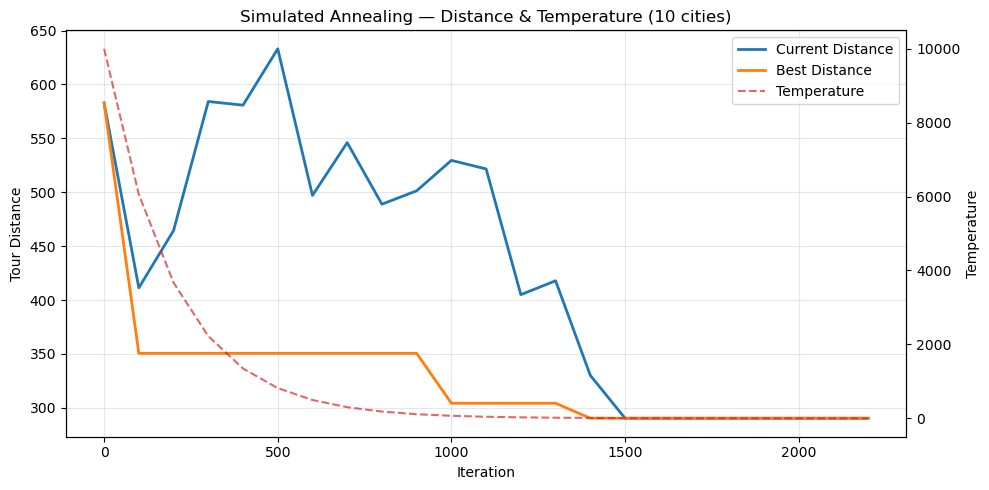

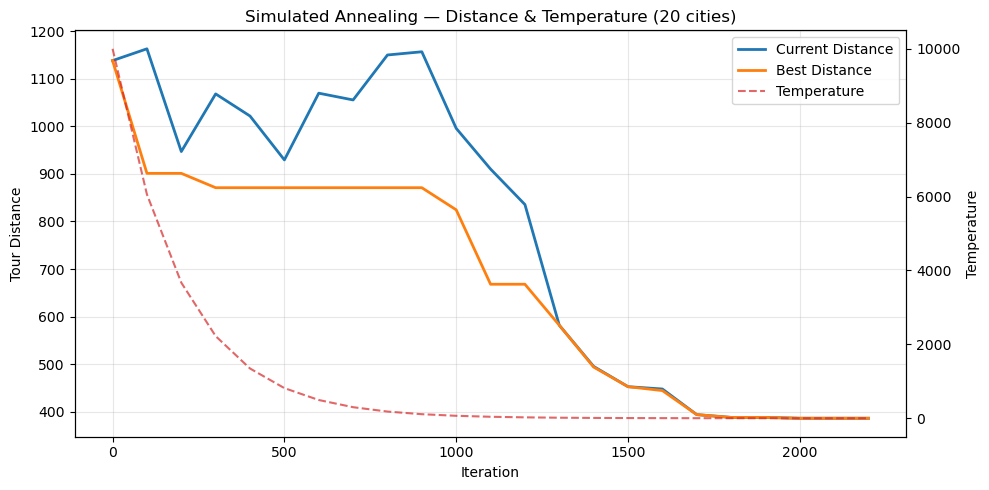

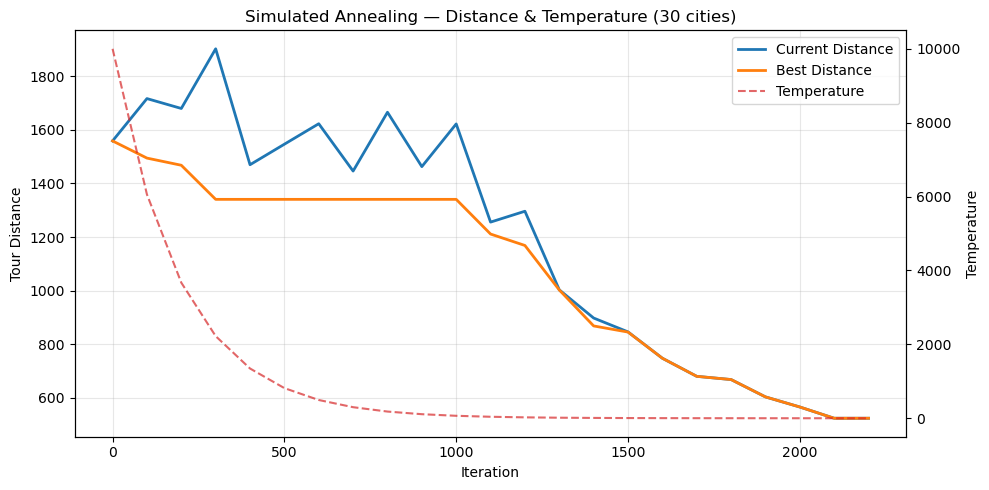

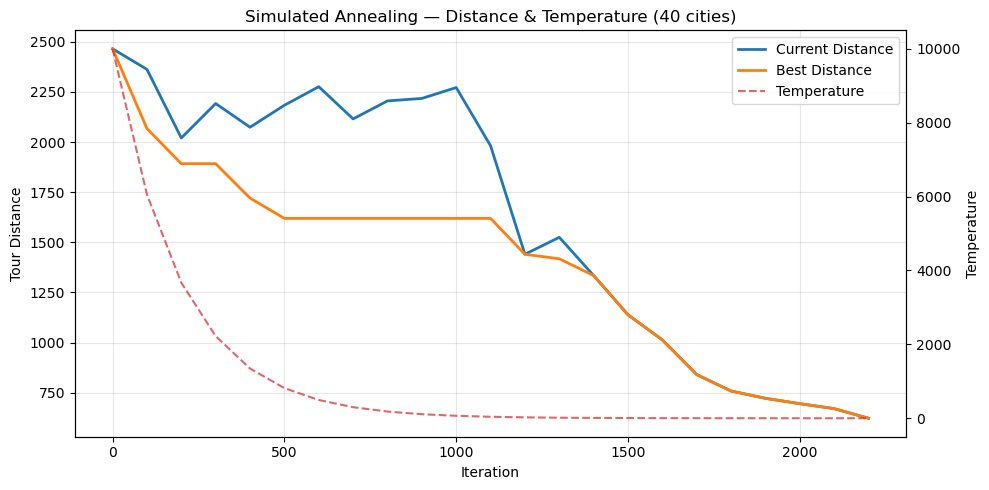

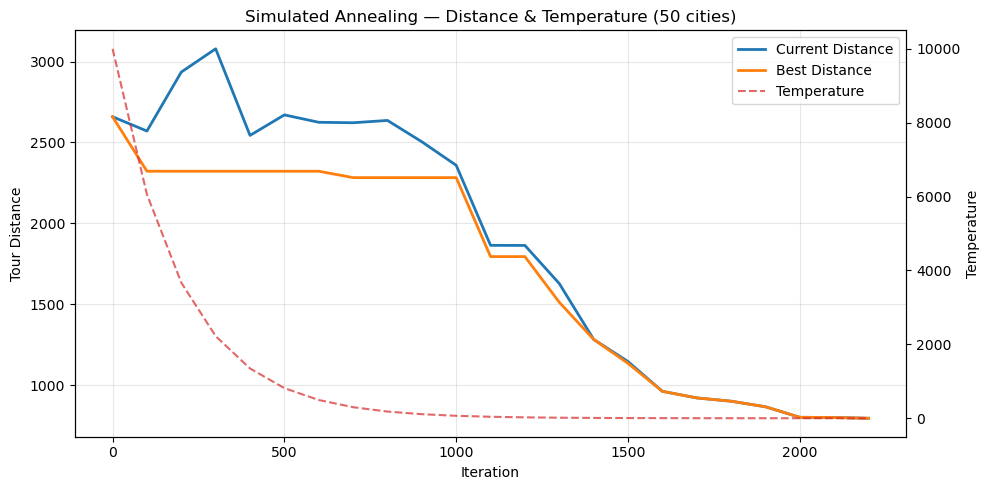

In [70]:
city_sizes = [10, 20, 30, 40, 50]

for n in city_sizes:
    hist_df = pd.read_csv(f"../results/sa_history_{n}cities.csv")
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.plot(hist_df["iteration"], hist_df["current_distance"],label="Current Distance", color="tab:blue", linewidth=2)
    ax1.plot(hist_df["iteration"], hist_df["best_distance"],label="Best Distance", color="tab:orange", linewidth=2)
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Tour Distance")
    ax1.grid(True, alpha=0.3)
    ax2 = ax1.twinx()
    ax2.plot(hist_df["iteration"], hist_df["temperature"],label="Temperature", color="tab:red", linestyle="--", linewidth=1.5, alpha=0.7)
    ax2.set_ylabel("Temperature")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.title(f"Simulated Annealing — Distance & Temperature ({n} cities)")
    plt.tight_layout()
    plt.show()

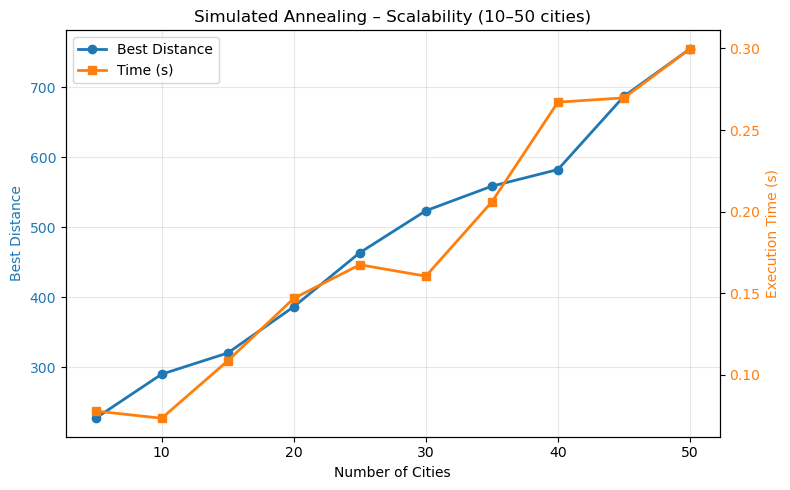

In [73]:
df = pd.read_csv("../results/sa_history_10-50_cities.csv")
fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(df["n_cities"], df["best_distance"], marker="o",color="tab:blue", label="Best Distance", linewidth=2)
ax1.set_xlabel("Number of Cities")
ax1.set_ylabel("Best Distance", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df["n_cities"], df["time_sec"], marker="s",color="tab:orange", label="Time (s)", linewidth=2)
ax2.set_ylabel("Execution Time (s)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Simulated Annealing – Scalability (10–50 cities)")
plt.tight_layout()
plt.show()


## Hyper parameter tuning

# Reference 

Simulated Annealing From Scratch. Available At: https://machinelearningmastery.com/simulated-annealing-from-scratch-in-python/ (Accessed: November 16, 2025)

Euclidean Distance measuring. Available At : https://en.wikipedia.org/wiki/Euclidean_distance , https://flexiple.com/python/calculate-distance-python (Accessed : November 16, 2025)

List-Based Simulated Annealing Algorithm for Traveling Salesman Problem. Available At: https://pmc.ncbi.nlm.nih.gov/articles/PMC4808530/ (Accessed: November 18, 2025) 

Difference Between Hill Climbing and Simulated Annealing Algorithm. Available At: https://www.geeksforgeeks.org/machine-learning/difference-between-hill-climbing-and-simulated-annealing-algorithm/ (Accessed: November 25, 2025)

Difference Between Hill Climbing and Simulated Annealing Algorithm. Available At: https://www.tutorialspoint.com/difference-between-hill-climbing-and-simulated-annealing-algorithm (Accessed: November 25, 2025)